# Daten über SRU-Schnittstelle abrufen

## Informationen über die Schnittstelle

<https://uri.gbv.de/database/gvk>

In [1]:
import requests
from lxml import etree

## Erstkontakt mit API

In [2]:
response = requests.get("https://sru.k10plus.de/gvk")

In [3]:
xml = response.content

## Anfrage spezifizieren

In [4]:
url = "https://sru.k10plus.de/gvk"
parameters = {
    'version' : '1.1',
    'operation' : 'searchRetrieve',
    'query' : 'pica.all = computer metadaten',
    'recordSchema' : 'marcxml', # oder: "mods", "picaxml", "dc" ..
    'maximumRecords' : '100',
    'startRecord' : 1
}

In [5]:
response = requests.get(url, params = parameters)

In [6]:
xml = response.content

## XML parsen

In [7]:
xmltree = etree.fromstring(xml)

In [8]:
xmltree

<Element {http://www.loc.gov/zing/srw/}searchRetrieveResponse at 0x106f4d300>

In [9]:
xmltree.xpath('//marc:record', namespaces = { 'marc' : 'http://www.loc.gov/MARC21/slim' })

[<Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f080>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4ecc0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4ed00>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4efc0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4c200>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f180>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f1c0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f200>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f240>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f140>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f280>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f2c0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f300>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f340>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f4f380>,
 <Element 

## Problem: Trefferzahl > 100

In [10]:
trefferzahl = xmltree.xpath('zs:numberOfRecords/text()', namespaces = { 'zs' : 'http://www.loc.gov/zing/srw/' })

In [11]:
trefferzahl

['246']

## In 100er-Schritten bis zum Ende

In [12]:
for start in range(1, int(trefferzahl[0]) + 1, 100):
    print(start)

1
101
201


In [13]:
for start in range(1, int(trefferzahl[0]) + 1, 100):
    print("Start bei ", start)
    url = "https://sru.k10plus.de/gvk"
    parameters = {
        'version' : '1.1',
        'operation' : 'searchRetrieve',
        'query' : 'pica.all = computer metadaten',
        'recordSchema' : 'marcxml', # oder: "mods", "picaxml", "dc" ..
        'maximumRecords' : '100',
        'startRecord' : start # <- WICHTIG!
    }
    response = requests.get(url, params = parameters)
    xmltree = etree.fromstring(response.content)

Start bei  1
Start bei  101
Start bei  201


## Ergebnisse einsammeln

In [14]:
ergebnisliste = []

for start in range(1, int(trefferzahl[0]) + 1, 100):
    print("Start bei ", start)
    url = "https://sru.k10plus.de/gvk"
    parameters = {
        'version' : '1.1',
        'operation' : 'searchRetrieve',
        'query' : 'pica.all = computer metadaten',
        'recordSchema' : 'marcxml', # oder: "mods", "picaxml", "dc" ..
        'maximumRecords' : '100',
        'startRecord' : start # <- WICHTIG!
    }
    response = requests.get(url, params = parameters)
    xmltree = etree.fromstring(response.content)
    ergebnisliste.extend(xmltree.xpath('//marc:record', namespaces = { 'marc' : 'http://www.loc.gov/MARC21/slim' }))

Start bei  1
Start bei  101
Start bei  201


In [15]:
ergebnisliste

[<Element {http://www.loc.gov/MARC21/slim}record at 0x10693d800>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f588c0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f58a00>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f58240>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f59ec0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f59f00>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f59f80>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f59a00>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f59480>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f58640>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f585c0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f5aa80>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f5a940>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f5a9c0>,
 <Element {http://www.loc.gov/MARC21/slim}record at 0x106f5aa40>,
 <Element 

## Daten analysieren

In [16]:
print(
    etree
    .tostring(
        ergebnisliste[87]
        )
        .decode('utf-8')
    )

<record xmlns="http://www.loc.gov/MARC21/slim" xmlns:zs="http://www.loc.gov/zing/srw/">
  <leader>     cam a22      c 4500</leader>
  <controlfield tag="001">87380323X</controlfield>
  <controlfield tag="003">DE-627</controlfield>
  <controlfield tag="005">20200122035815.0</controlfield>
  <controlfield tag="007">tu</controlfield>
  <controlfield tag="008">161206s2016    sz |||||      00| ||eng c</controlfield>
  <datafield tag="020" ind1=" " ind2=" ">
    <subfield code="a">9783319491561</subfield>
    <subfield code="9">978-3-319-49156-1</subfield>
  </datafield>
  <datafield tag="035" ind1=" " ind2=" ">
    <subfield code="a">(DE-627)87380323X</subfield>
  </datafield>
  <datafield tag="035" ind1=" " ind2=" ">
    <subfield code="a">(DE-576)9873803238</subfield>
  </datafield>
  <datafield tag="035" ind1=" " ind2=" ">
    <subfield code="a">(DE-599)GBV87380323X</subfield>
  </datafield>
  <datafield tag="035" ind1=" " ind2=" ">
    <subfield code="a">(OCoLC)965361543</subfield>
  </

In [17]:
bkls = []

for element in ergebnisliste:
    bkl = element.xpath('//marc:datafield[@tag=084 and marc:subfield[@code="2"] = "bkl"]/marc:subfield[@code="a"]/text()', namespaces = { 'marc' : 'http://www.loc.gov/MARC21/slim' })
    for b in bkl:
        bkls.append(b)

20.03
54.55
20.03
54.55
54.38
54.72
54.80
54.08
54.72
54.62
54.64
54.72
54.80
54.72
54.80
38.81
54.62
54.00
54.08
54.80
38.81
54.62
54.32
54.80
54.32
54.80
54.80
54.80
81.68
81.68
54.80
54.80
06.54
06.35
54.80
06.54
06.35
54.80
06.54
54.80
06.35
17.87
10.03
18.00
54.64
54.80
54.80
54.80
54.64
54.80
54.80
54.80
54.80
54.80
21.37
54.73
11.01
11.05
05.30
54.53
54.65
54.64
06.74
54.65
54.80
54.73
54.73
54.80
06.70
54.80
54.64
54.00
24.33
54.00
24.33
15.15
54.73
06.80
54.62
54.61
06.54
06.74
06.90
54.75
06.74
06.35
54.80
54.87
54.74
54.72
06.74
06.35
54.80
54.33
06.74
06.11
06.70
06.21
54.64
54.32
06.70
06.74
06.35
54.80
54.62
54.72
54.54
54.64
85.20
54.38
54.08
71.43
17.63
17.50
18.09
18.00
17.49
17.46
20.03
54.55
20.03
54.55
54.38
54.72
54.80
54.08
54.72
54.62
54.64
54.72
54.80
54.72
54.80
38.81
54.62
54.00
54.08
54.80
38.81
54.62
54.32
54.80
54.32
54.80
54.80
54.80
81.68
81.68
54.80
54.80
06.54
06.35
54.80
06.54
06.35
54.80
06.54
54.80
06.35
17.87
10.03
18.00
54.64
54.80
54.80
54.80
54.6

In [18]:
from collections import Counter

Counter(bkls)

Counter({'54.72': 3230,
         '54.80': 3192,
         '54.62': 2884,
         '06.74': 2276,
         '54.64': 2184,
         '54.38': 1300,
         '54.87': 1246,
         '54.32': 930,
         '54.65': 900,
         '06.35': 846,
         '54.55': 800,
         '05.38': 738,
         '85.20': 638,
         '54.08': 600,
         '54.73': 592,
         '06.70': 584,
         '06.54': 446,
         '54.00': 346,
         '54.53': 300,
         '17.46': 300,
         '81.68': 246,
         '54.61': 246,
         '20.03': 200,
         '38.81': 200,
         '18.00': 200,
         '24.33': 200,
         '54.75': 200,
         '54.33': 200,
         '54.82': 200,
         '53.72': 200,
         '74.48': 138,
         '17.87': 100,
         '10.03': 100,
         '21.37': 100,
         '11.01': 100,
         '11.05': 100,
         '05.30': 100,
         '15.15': 100,
         '06.80': 100,
         '06.90': 100,
         '54.74': 100,
         '06.11': 100,
         '06.21': 100,
    

In [19]:
ueberkategorien = []
for b in bkls:
    ueberkategorien.append(b.split(".")[0])

Counter(ueberkategorien)

Counter({'54': 19842,
         '06': 4698,
         '05': 884,
         '85': 738,
         '17': 700,
         '81': 438,
         '18': 300,
         '20': 200,
         '38': 200,
         '11': 200,
         '24': 200,
         '53': 200,
         '74': 138,
         '43': 138,
         '10': 100,
         '21': 100,
         '15': 100,
         '71': 100,
         '02': 100,
         '86': 100,
         '88': 100,
         '44': 100,
         '50': 46,
         '31': 46})

## Ergebnisse visualisieren

In [20]:
from matplotlib import pyplot as plt

In [21]:
c = Counter(ueberkategorien).most_common()

xs = []
ys = []

for _ in c:
    x,y = _
    xs.append(x)
    ys.append(y)


<BarContainer object of 24 artists>

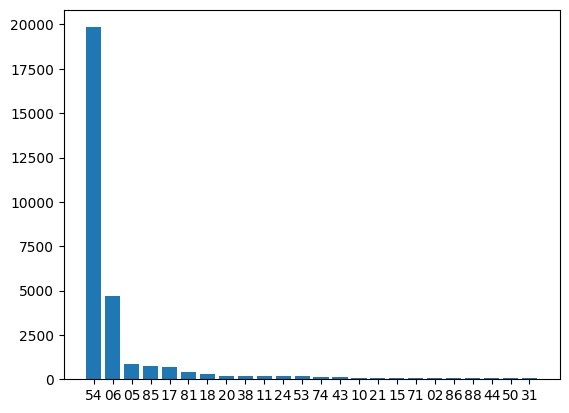

In [22]:
plt.bar(xs, ys)